In [ ]:



import pandas as pd

#Exercise 0
# 1. Upload the file (use `r' to avoid path errors on Windows)
path = r'c:\Users\alfre\OneDrive\Desktop\Big Data\Archive\data\symbol_info_3-25.csv'

df = pd.read_csv(path)


totale_iniziale = len(df)

# 2. Keep only active companies (is_actively_trading == 1)
df_clean = df[df['is_actively_trading'] == 1].copy()

# 3. Remove ETF (is_etf == 0) e funds (is_fund == 0)
df_clean = df_clean[df_clean['is_etf'] == 0].copy()
df_clean = df_clean[df_clean['is_fund'] == 0].copy()

# 4. Filter by my assigned sector
my_sector = 'Financial Services' 
df_sector = df_clean[df_clean['sector'] == my_sector]

# Check the results
print(f"Settore selezionato: {my_sector}")
print(f"Numero di aziende nel data set non pulito: {totale_iniziale}")
print(f"Numero di aziende trovate in tutti i settori: {len(df_clean)}")
print(f"Numero di aziende trovate: {len(df_sector)}")
print(df_sector[['symbol', 'company_name', 'sector']].head())


Settore selezionato: Financial Services
Numero di aziende nel data set non pulito: 1000
Numero di aziende trovate in tutti i settori: 999
Numero di aziende trovate: 151
   symbol                 company_name              sector
7   BRK-A      Berkshire Hathaway Inc.  Financial Services
8   BRK-B  Berkshire Hathaway Inc. New  Financial Services
14    JPM        JP Morgan Chase & Co.  Financial Services
15      V                    Visa Inc.  Financial Services
17     MA      Mastercard Incorporated  Financial Services


In [ ]:
#EXERCISE 1

#first we compute the mean and the median


media_mc = df_sector['market_cap'].mean()
mediana_mc = df_sector['market_cap'].median()

#let's make a control
print(f"La media è: {media_mc}")
print(f"La mediana è: {mediana_mc}")

La media è: 69564720205.98676
La mediana è: 22018596864.0


COMMENT ON MEAN VS MEDIAN:
In the Financial Services sector, the mean market capitalization is significantly higher than the median. 
This indicates a strongly right-skewed distribution. The market is populated by a large number of 
small-to-medium financial firms, alongside a few massive industry giants (e.g., major banks or payment processors). 
These few outliers pull the mean up, making the median a much more accurate representation of the "typical" 
company size in this sector.

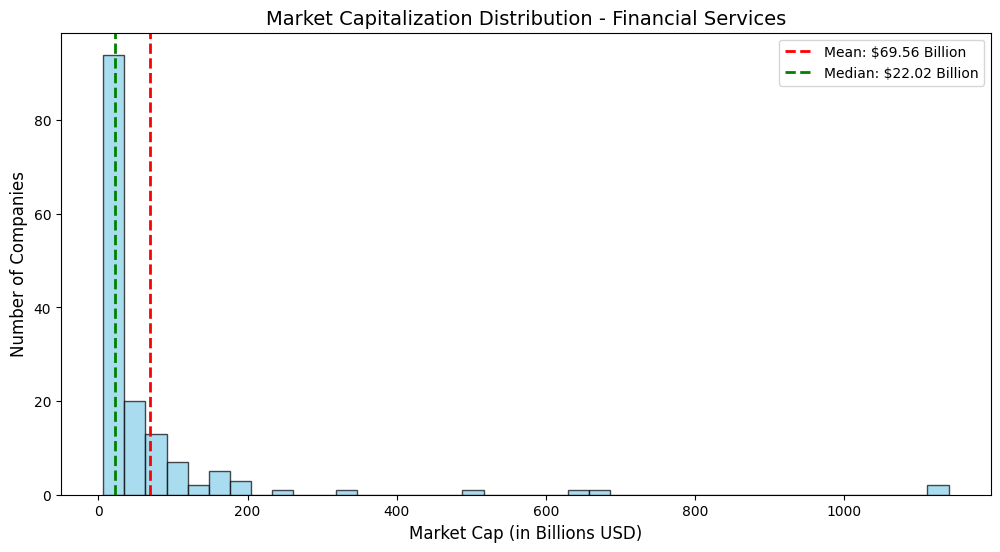

In [298]:
import matplotlib.pyplot as plt

# --- PLOTTING THE HISTOGRAM ---

# To make the x-axis readable, we divide the market cap by 1 billion (1e9)
market_cap_billions = df_sector['market_cap'] / 1e9
mean_bn = media_mc / 1e9
median_bn = mediana_mc / 1e9

# Create the figure
plt.figure(figsize=(12, 6))

# Plot the histogram
# We use 40 bins to get a good granularity of the distribution
plt.hist(market_cap_billions, bins=40, color='skyblue', edgecolor='black', alpha=0.7)

# Add the vertical line for the MEAN (Red)
plt.axvline(mean_bn, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: ${mean_bn:.2f} Billion')

# Add the vertical line for the MEDIAN (Green)
plt.axvline(median_bn, color='green', linestyle='dashed', linewidth=2, 
            label=f'Median: ${median_bn:.2f} Billion')

# Add Titles and Labels
plt.title('Market Capitalization Distribution - Financial Services', fontsize=14)
plt.xlabel('Market Cap (in Billions USD)', fontsize=12)
plt.ylabel('Number of Companies', fontsize=12)

# Show the legend which contains our annotations
plt.legend()

# Display the plot
plt.show()

STATISTICAL VERIFICATION:
The summary statistics generated via the .describe() method confirm the accuracy of our previous calculations. 
Specifically, after adjusting the scale to billions:
1. The calculated Mean perfectly matches the 'mean' value in the summary table.
2. The calculated Median perfectly matches the 50th percentile ('50%') in the summary table.

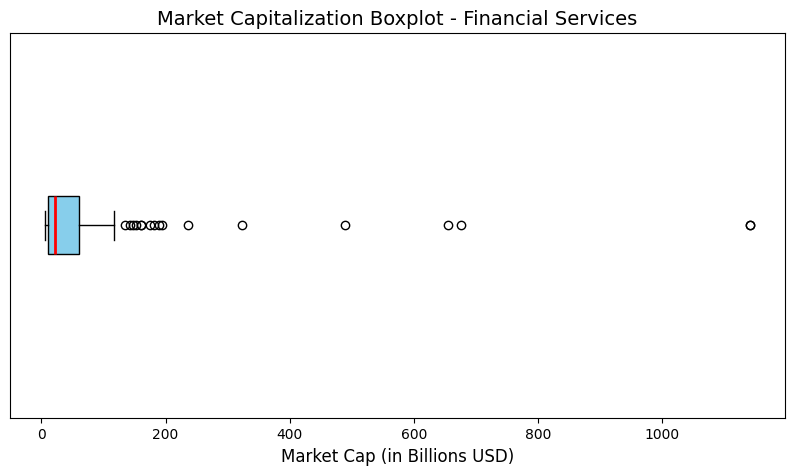

Aziende rimosse (> 300B): 6
Aziende rimanenti: 145


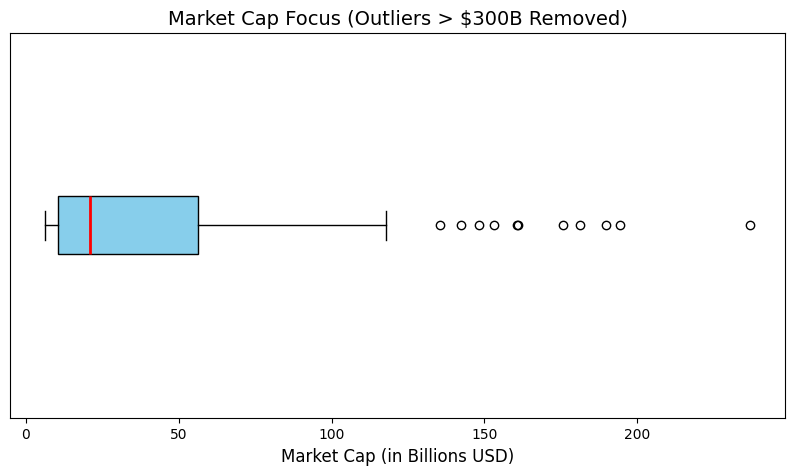

In [ ]:
# --- EXERCISE 2: OUTLIER DETECTION (BOXPLOT) ---


# Creiamo la figura per il grafico
plt.figure(figsize=(10, 5))

#I chose (10, 5) because for a single horizontal boxplot we don't need an image that's too tall, but we do need it to be wide enough to fit the billions axis.

# Let's create the horizontal boxplot (vert=False)
plt.boxplot(market_cap_billions, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

# Let's add titles and labels
plt.title('Market Capitalization Boxplot - Financial Services', fontsize=14)
plt.xlabel('Market Cap (in Billions USD)', fontsize=12)
# Let's remove the numbers on the Y-axis and put the sector name
plt.yticks([]) 

# Let's show the graph
plt.show()

# From the previous boxplot, we can clearly see that the 
#vast majority of the sector is concentrated under $300 billion. Above that, all cases are exceptional
billion_threshold = 300
limite = billion_threshold * 1e9 

# Let's create the clean dataset
df_no_outliers = df_sector[df_sector['market_cap'] <= limite].copy()

# Let's print the report
print(f"Aziende rimosse (> {billion_threshold}B): {len(df_sector) - len(df_no_outliers)}")
print(f"Aziende rimanenti: {len(df_no_outliers)}")

# Let's draw the new Boxplot
plt.figure(figsize=(10, 5))
plt.boxplot(df_no_outliers['market_cap'] / 1e9, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Market Cap Focus (Outliers > $300B Removed)', fontsize=14)
plt.xlabel('Market Cap (in Billions USD)', fontsize=12)
plt.yticks([]) 

plt.show()

COMMENT ON OUTLIER REMOVAL:
Based on the visual inspection of the initial boxplot, the sector exhibits extreme right-skewness 
due to a few mega-cap financial institutions. To prevent these giants from skewing the industry 
averages in the following steps, I set a manual threshold of $300 Billion. 
Companies above this threshold are considered outliers for the purpose of this analysis and have been removed. 
From this point forward, 'df_no_outliers' will be used.

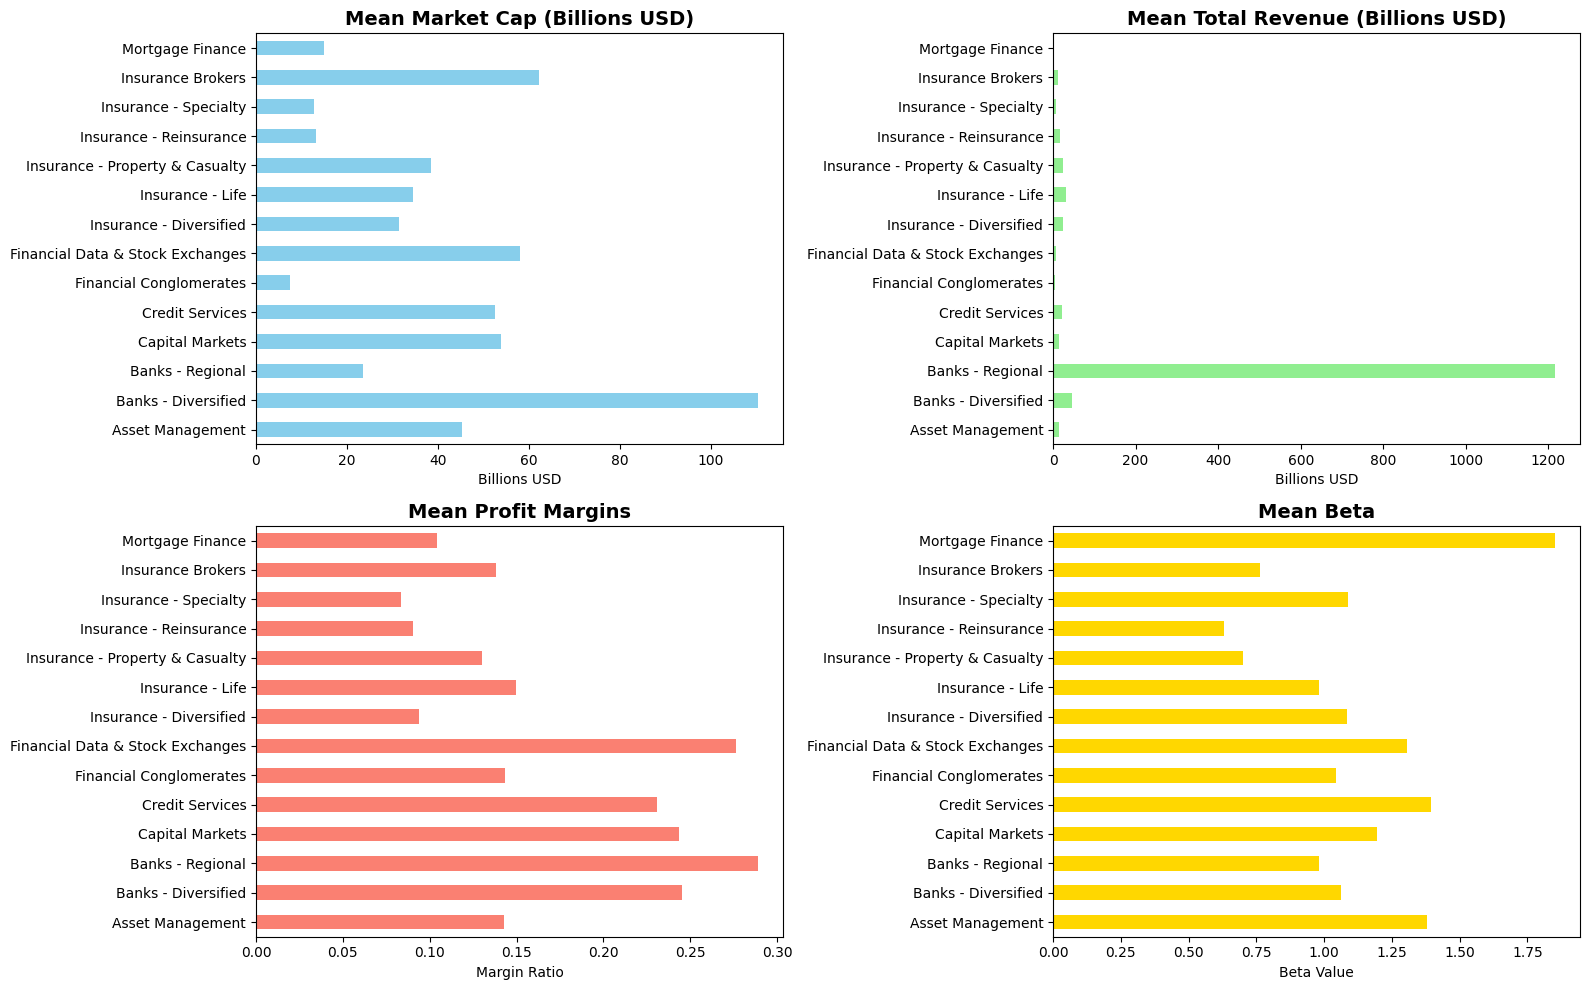

In [ ]:
# --- EXERCISE 3: INDUSTRY COMPARISON ---

# 1. We group by 'industry' and calculate the average for the 4 metrics
# Note: We use df_no_outliers, the clean dataset from Point 2!
metrics = ['market_cap', 'total_revenue', 'profit_margins', 'beta']
industry_means = df_no_outliers.groupby('industry')[metrics].mean()

# 2. Let's create the basic figure with 4 sub-charts (2 rows x 2 columns)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# 3. Let's draw the 4 horizontal bar graphs (.plot(kind='barh'))
# We use sort_values() to sort them from smallest to largest

# Top Left Chart [Row 0, Column 0]: Market Cap (in billions)
(industry_means['market_cap'] / 1e9).plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Mean Market Cap (Billions USD)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Billions USD')
axes[0, 0].set_ylabel('') # I'm removing the "industry" wording for visual cleanliness.

# Top right chart [Row 0, Column 1]: Total Revenue (in billions)
(industry_means['total_revenue'] / 1e9).plot(kind='barh', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Mean Total Revenue (Billions USD)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Billions USD')
axes[0, 1].set_ylabel('')

# Bottom left chart [Row 1, Column 0]: Profit Margins
industry_means['profit_margins'].plot(kind='barh', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Mean Profit Margins', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Margin Ratio')
axes[1, 0].set_ylabel('')

# Bottom right graph [Row 1, Column 1]: Beta
industry_means['beta'].plot(kind='barh', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Mean Beta', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Beta Value')
axes[1, 1].set_ylabel('')

# This feature prevents the text on one graph from overlapping another.
plt.tight_layout()

#Let's show the final result
plt.show()

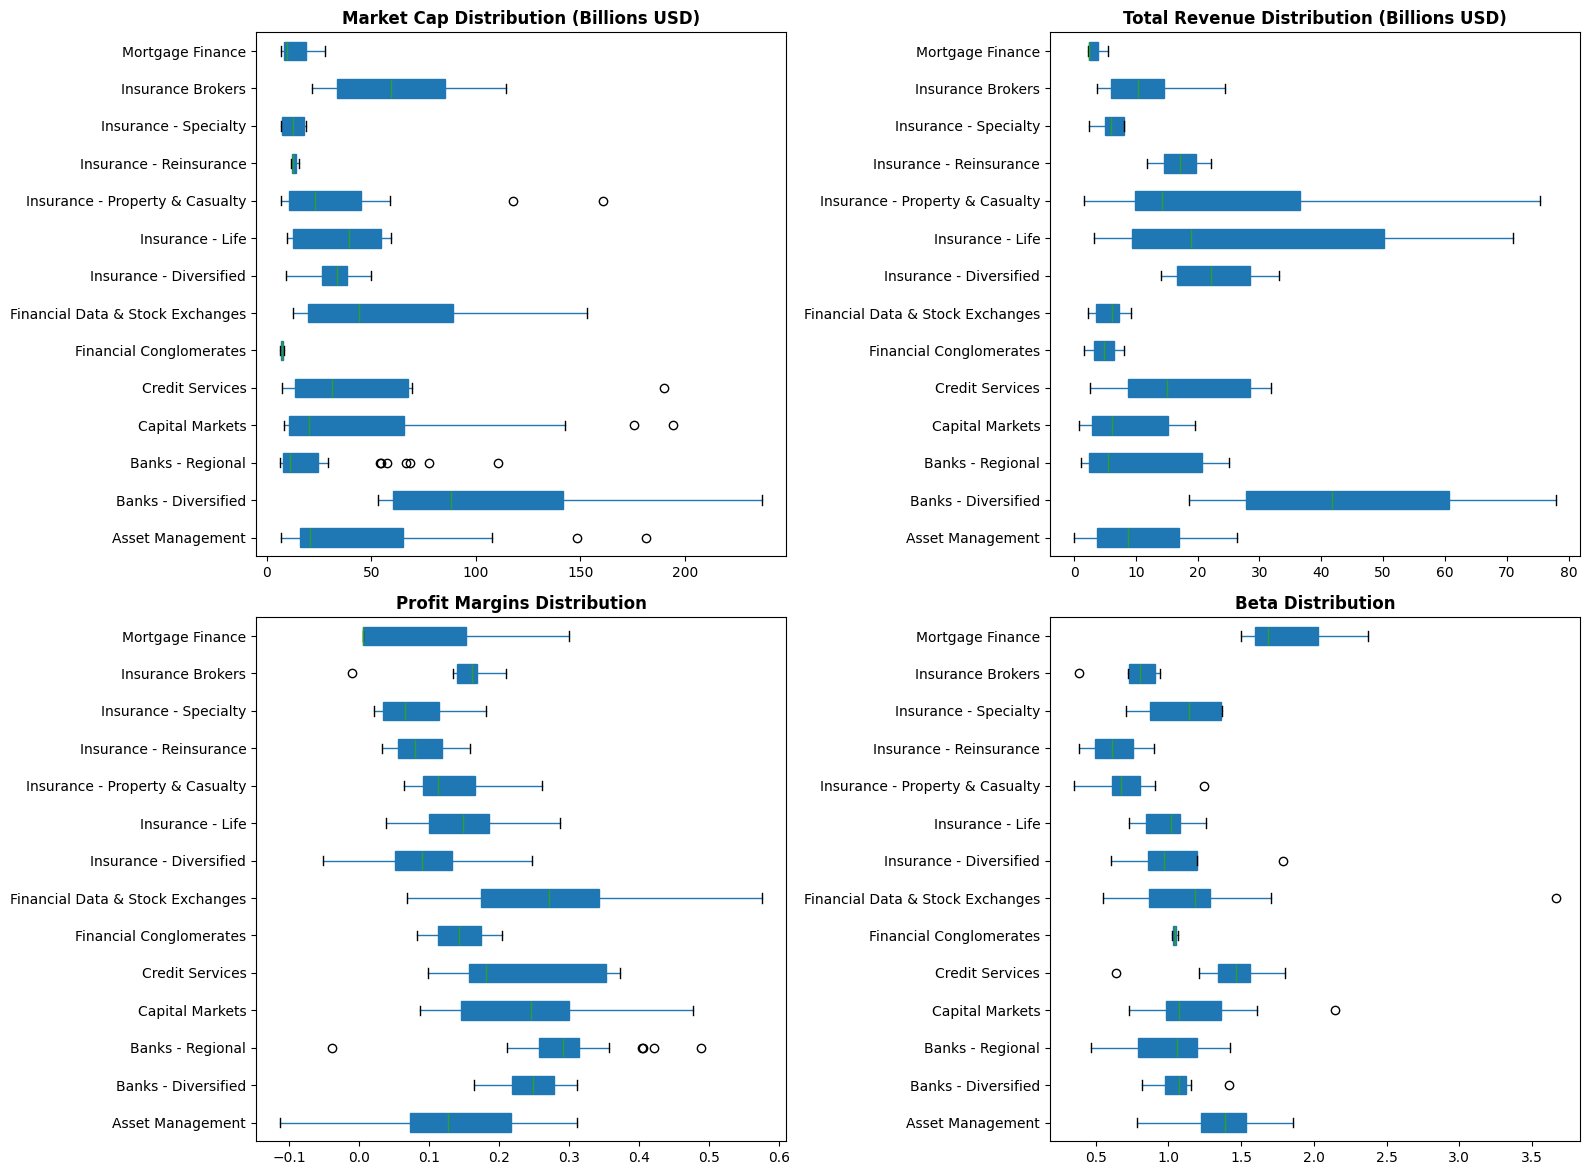

In [ ]:
# --- ESERCIZIO 4: FULL DISTRIBUTIONS BY INDUSTRY ---

# Let's create a copy of the data just to immediately divide Market Cap and Revenue by 1 billion
df_plot = df_no_outliers.copy()
df_plot['market_cap'] = df_plot['market_cap'] / 1e9
df_plot['total_revenue'] = df_plot['total_revenue'] / 1e9

# Let's create the 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# 1. Market Cap
df_plot.boxplot(column='market_cap', by='industry', ax=axes[0, 0], vert=False, grid=False, patch_artist=True)
axes[0, 0].set_title('Market Cap Distribution (Billions USD)', fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('')

# 2. Total Revenue
df_plot.boxplot(column='total_revenue', by='industry', ax=axes[0, 1], vert=False, grid=False, patch_artist=True, showfliers=False)  #i add showfliers=False to hide outliers, make the graph automatically zoom in on the boxes.
axes[0, 1].set_title('Total Revenue Distribution (Billions USD)', fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')

# 3. Profit Margins
df_plot.boxplot(column='profit_margins', by='industry', ax=axes[1, 0], vert=False, grid=False, patch_artist=True)
axes[1, 0].set_title('Profit Margins Distribution', fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('')

# 4. Beta
df_plot.boxplot(column='beta', by='industry', ax=axes[1, 1], vert=False, grid=False, patch_artist=True)
axes[1, 1].set_title('Beta Distribution', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')

# Final cleaning
plt.suptitle('') # Removes the automatic title that Pandas sets by default
plt.tight_layout()

# Let's show the graph!
plt.show()

ESERCIZIO 5: JUSTIFICATION AND FILTER

I chose these four industries for the following reasons:
1. Financial Data & Stock Exchanges: High efficiency (low revenue vs. high margins).
2. Mortgage Finance: High risk/volatility (high beta) despite small size.
3. Banks - Diversified: High variability in size (wide boxes for Cap/Revenue)
but high consistency in returns (narrow boxes for Margins/Beta).
4. Insurance - Life: Strong disparity in revenue between companies but homogeneous market risk.

In [302]:
# 1. Let's create a list with the exact names of the chosen industries
selected_industries = [
    'Financial Data & Stock Exchanges',
    'Mortgage Finance',
    'Banks - Diversified',
    'Insurance - Life'
]

# 2. I filter the dataset using .isin()
df_focus = df_no_outliers[df_no_outliers['industry'].isin(selected_industries)]

# 3. Let's print how many companies we have left for confirmation
print(f"Aziende prima del filtro: {len(df_no_outliers)}")
print(f"Aziende dopo il filtro: {len(df_focus)}")

# Let's preview our new mini-dataset
df_focus.head()

Aziende prima del filtro: 145
Aziende dopo il filtro: 29


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
36,WFC,Wells Fargo & Company,Financial Services,Banks - Diversified,236789383168,179842285568,72.519997,72.519997,81.500000,50.150002,...,0.2793,15647053,2.03,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:29
64,RY,Royal Bank Of Canada,Financial Services,Banks - Diversified,160726958080,18446743953848131584,113.599998,113.809998,128.050003,95.839996,...,0.4638,1168233,5.49,NYQ,NYQ,Canada,0,0,1,2025-03-22 04:50:46
67,SPGI,S&P Global Inc.,Financial Services,Financial Data & Stock Exchanges,153247465472,167952465920,497.880005,497.200012,545.390015,407.690002,...,0.2947,1356543,2.67,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:50
79,C,"Citigroup, Inc.",Financial Services,Banks - Diversified,135477886976,15625838592,71.980003,71.820000,84.739998,53.509998,...,0.3664,15289683,2.51,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:55
107,TD,Toronto Dominion Bank (The),Financial Services,Banks - Diversified,104969248768,18446744035028250624,59.529999,59.900002,64.910004,51.250000,...,0.8708,2216125,5.40,NYQ,NYQ,Canada,0,0,1,2025-03-22 04:51:22


ESERCIZIO 6: BUBBLE CHART & QUADRANTS ANALYSIS

Documentation of Encodings:
1. X-Axis (market_cap): Represents the market valuation/size of the company. 
   I chose this to test the "Too Big to Fail" hypothesis.
2. Y-Axis (beta): Represents the market risk and volatility. Paired with the X-axis, 
   it reveals if larger companies are inherently more stable than smaller ones.
3. Bubble Size (total_revenue): Represents the actual volume of business. 
   This adds a layer of depth, showing if high market caps are actually backed by massive revenues.
4. Bubble Color (industry): Categorizes the bubbles by our 4 selected industries 
   to identify cluster patterns and sector behaviors.

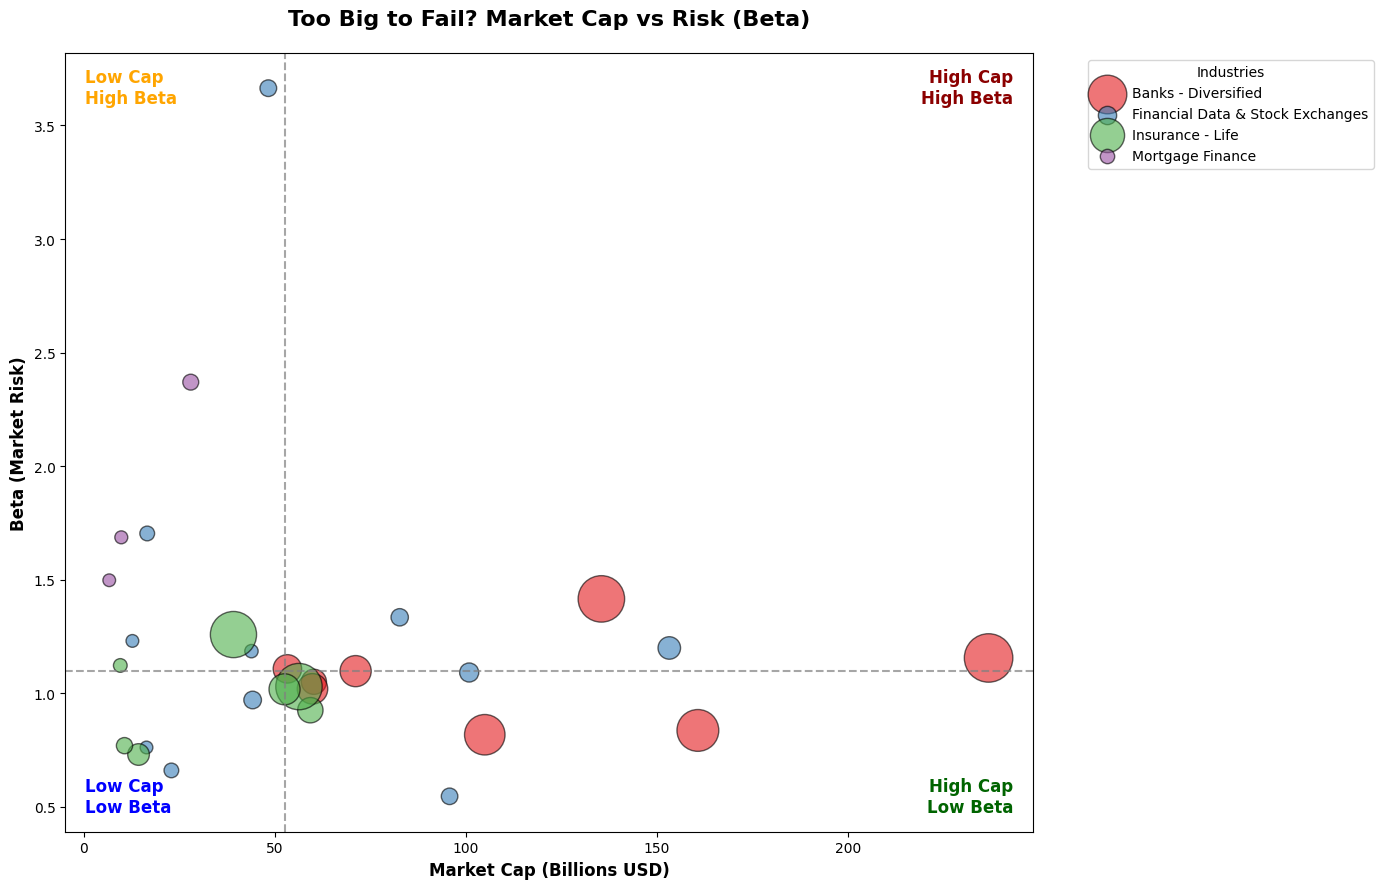

In [303]:
# Let's create a copy and divide the money by 1 billion, so the numbers on the axis are readable
df_plot = df_focus.copy()
df_plot['market_cap'] = df_plot['market_cap'] / 1e9
df_plot['total_revenue'] = df_plot['total_revenue'] / 1e9

# Let's set up the giant canvas
plt.figure(figsize=(14, 9))

# Let's find the medians to draw the cross of the quadrants
centro_x = df_plot['market_cap'].median()
centro_y = df_plot['beta'].median()

# List of our 4 industries and 4 colors to use
industrie = df_plot['industry'].unique()
colori = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'] # Red, Blue, Green, Purple

# Let's draw the Bubble Chart using matplotlib (create a group for each industry)
for i, industria in enumerate(industrie):
    dati_industria = df_plot[df_plot['industry'] == industria]
    
    # Let's calculate the size of the bubble:
    # We multiply the revenue to make it visible, and add a base (+50)
 # so that companies with almost zero revenue don't become invisible.
    
    dimensione_bolle = (dati_industria['total_revenue'] * 15) + 50
    
    plt.scatter(
        x=dati_industria['market_cap'],
        y=dati_industria['beta'],
        s=dimensione_bolle,
        color=colori[i],
        alpha=0.6,
        edgecolors='black',
        label=industria
    )

# We draw the cross to create the 4 quadrants
plt.axvline(centro_x, color='grey', linestyle='--', alpha=0.7)
plt.axhline(centro_y, color='grey', linestyle='--', alpha=0.7)

# Writings at the 4 corners (Using the "absolute" screen coordinates from 0 to 1)
ax = plt.gca()

# Quadrant 1: Top Right (Large and Risky)
ax.text(0.98, 0.98, 'High Cap\nHigh Beta', transform=ax.transAxes, 
        color='darkred', fontsize=12, fontweight='bold', ha='right', va='top')

# Quadrant 2: Bottom Right (The Armored Giants / Safe)
ax.text(0.98, 0.02, 'High Cap\nLow Beta', transform=ax.transAxes, 
        color='darkgreen', fontsize=12, fontweight='bold', ha='right', va='bottom')

# Quadrant 3: Top Left (Small and Reckless)
ax.text(0.02, 0.98, 'Low Cap\nHigh Beta', transform=ax.transAxes, 
        color='orange', fontsize=12, fontweight='bold', ha='left', va='top')

# Quadrant 4: Bottom Left (Small and Stable)
ax.text(0.02, 0.02, 'Low Cap\nLow Beta', transform=ax.transAxes, 
        color='blue', fontsize=12, fontweight='bold', ha='left', va='bottom')

# Final embellishments
plt.title('Too Big to Fail? Market Cap vs Risk (Beta)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Market Cap (Billions USD)', fontsize=12, fontweight='bold')
plt.ylabel('Beta (Market Risk)', fontsize=12, fontweight='bold')

# Let's move the legend off the chart so as not to cover the bubbles
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Industries")
plt.tight_layout()

# Let's show the clean graph
plt.show()

EXERCISE 7:
I chose the "High Cap / Low Beta" quadrant because my goal is to analyze the most "solid" and resilient companies in the dataset. These industry giants are theoretically less volatile than the overall market. I want to test if they actually act as safe havens and maintain price stability during periods of geopolitical turbulence, such as the tensions in the Strait of Hormuz.

In [304]:
# We filter the companies in Quadrant 2 (High Cap & Low Beta)
#We use the "&" symbol which in Pandas means "AND" (both conditions must be true)
df_quadrante = df_plot[(df_plot['market_cap'] > centro_x) & (df_plot['beta'] < centro_y)]

print(len(df_quadrante))
print(df_quadrante)

8
    symbol                     company_name              sector  \
64      RY             Royal Bank Of Canada  Financial Services   
107     TD      Toronto Dominion Bank (The)  Financial Services   
113    ICE   Intercontinental Exchange Inc.  Financial Services   
120    CME                   CME Group Inc.  Financial Services   
197     BK  The Bank of New York Mellon Cor  Financial Services   
198    BNS   Bank Nova Scotia Halifax Pfd 3  Financial Services   
199    AFL               AFLAC Incorporated  Financial Services   
210    MET                    MetLife, Inc.  Financial Services   

                             industry  market_cap      enterprise_value  \
64                Banks - Diversified  160.726958  18446743953848131584   
107               Banks - Diversified  104.969249  18446744035028250624   
113  Financial Data & Stock Exchanges  100.887921          120167366656   
120  Financial Data & Stock Exchanges   95.759860           95715901440   
197               B

Since we found 8 companies, we will analyze all of them.

In [305]:
# Extracting the symbol directly into a list since we know they are <= 10
selected_symbol = df_quadrante['symbol'].tolist()

print("Symbols ready for analysis:", selected_symbol)

Symbols ready for analysis: ['RY', 'TD', 'ICE', 'CME', 'BK', 'BNS', 'AFL', 'MET']


In [306]:
!pip install yfinance
import yfinance as yf


# Downloading the daily data for the last 3 months
# Using period='3mo' automatically fetches the exact timeframe required
df_yfinance = yf.download(selected_symbol, period='3mo')

# We only need the daily closing prices, so we extract just the 'Close' column
df_close = df_yfinance['Close'].dropna(axis=1, how='all') #i add the .dropna... to remove the coloumn with all 'Nan'



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  8 of 8 completed


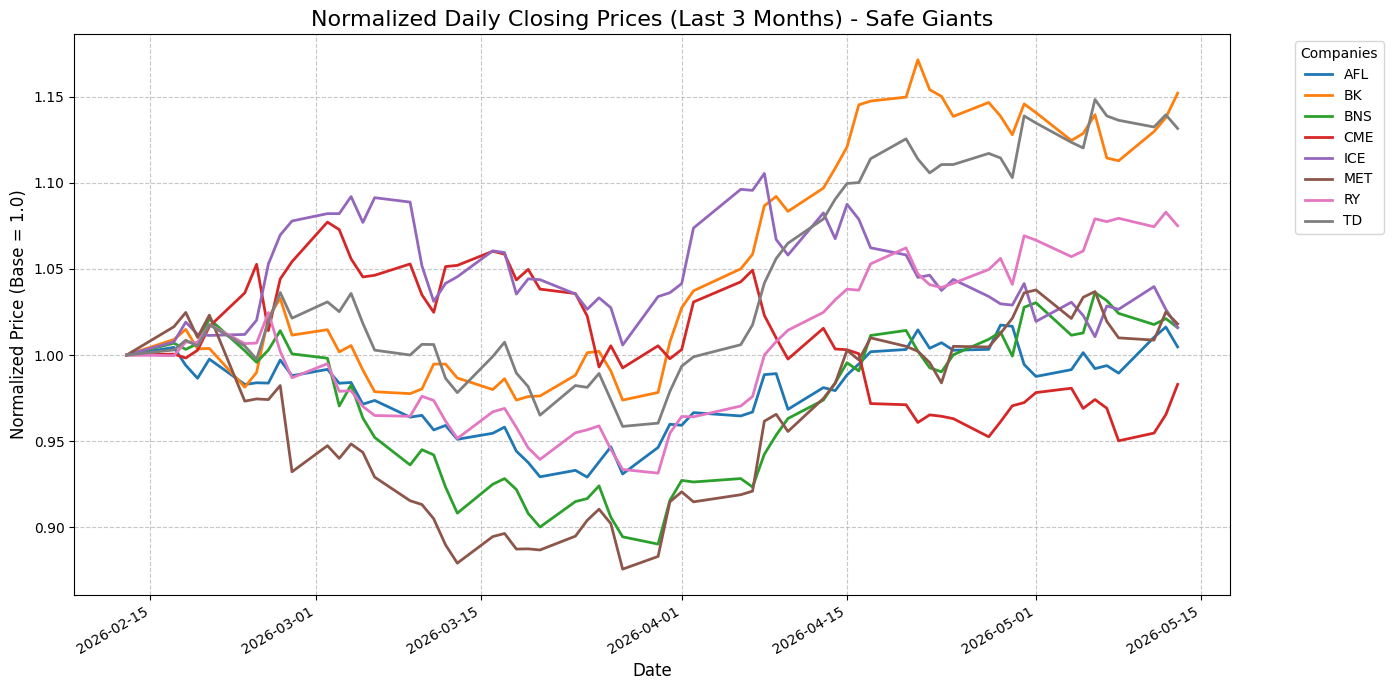

In [307]:
# Normalizing the data: dividing all rows by the first row (index 0)
# This forces all stock prices to start exactly at 1.0 on the first day
df_normalized = df_close / df_close.iloc[0]

# Creating the plot
# Pandas has a built-in plot function that automatically handles dates on the x-axis
plt.figure(figsize=(14, 7))
df_normalized.plot(ax=plt.gca(), linewidth=2)

# Adding titles and labels for clarity
plt.title('Normalized Daily Closing Prices (Last 3 Months) - Safe Giants', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price (Base = 1.0)', fontsize=12)

# Adding a grid to make it easier to read percentage changes
plt.grid(True, linestyle='--', alpha=0.7)

# Placing the legend outside the plot so it doesn't cover the lines
plt.legend(title='Companies', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjusting layout and displaying the chart
plt.tight_layout()
plt.show()

Observation on the Geopolitical Impact (Strait of Hormuz):
Looking at the normalized price chart for our "Safe Giants" (High Cap / Low Beta), the impact of the geopolitical tensions is visible but varies significantly among the companies.

1. Visibly Affected (Sharp Drop & Recovery): 
Companies like MET (brown), BNS (green), and AFL (blue) show a visible "V-shape" trend. They suffered a sharp drop during March. However, true to their "solid" nature, they didn't collapse. Instead, they showed clear signs of recovery starting in April, climbing back to their initial baseline (1.0).

2. Gradual Decline: 
CME (red) reacted differently. After an initial spike, it experienced a gradual, continuous decline over the 3-month period, ending as the worst performer in this specific timeframe.

3. Resilience (No Significant Impact): 
On the other hand, companies like BK (orange) and TD (grey) seemed almost completely unfazed by the geopolitical shock. They ignored the crisis and showed a steady upward trend.

Conclusion: 
The "Safe Giants" filter was effective. Despite a major global crisis, none of these companies suffered catastrophic losses, and those affected showed strong resilience and recovery.

EXERCISE 8:
I chose the "Low Cap / High Beta" quadrant because now i want to analyze the less "solid" and companies in the dataset. In order to verify their behavior in relation to the
current geopolitical situation, in particular the tensions in the Strait of Hormuz and compare with the companies in previous set.

In [308]:
# We filter the companies in Quadrant 4 (Low Cap & High Beta)
df_quadrante_4 = df_plot[(df_plot['market_cap'] < centro_x) & (df_plot['beta'] > centro_y)]

print(len(df_quadrante_4))

9


Since we found 9 companies, we will analyze all of them.

In [309]:
# Extracting the symbol directly into a list since we know they are <= 10
selected_symbol_2 = df_quadrante_4['symbol'].tolist()

print("Symbols ready for analysis:", selected_symbol_2)

Symbols ready for analysis: ['COIN', 'MSCI', 'PRU', 'RKT', 'TRU', 'MORN', 'UWMC', 'PRI', 'COOP']


In [310]:
# Downloading the daily data for the last 3 months
# Using period='3mo' automatically fetches the exact timeframe required
df_yfinance_2 = yf.download(selected_symbol_2, period='3mo')

# We only need the daily closing prices, so we extract just the 'Close' column
df_close_2 = df_yfinance_2['Close'].dropna(axis=1, how='all') #i remove the companies with all 'Nan'

[**********************78%************           ]  7 of 9 completed$COOP: possibly delisted; no price data found  (period=3mo) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  8 of 9 completed

1 Failed download:
['COOP']: possibly delisted; no price data found  (period=3mo) (Yahoo error = "No data found, symbol may be delisted")


Now we have 8 companies

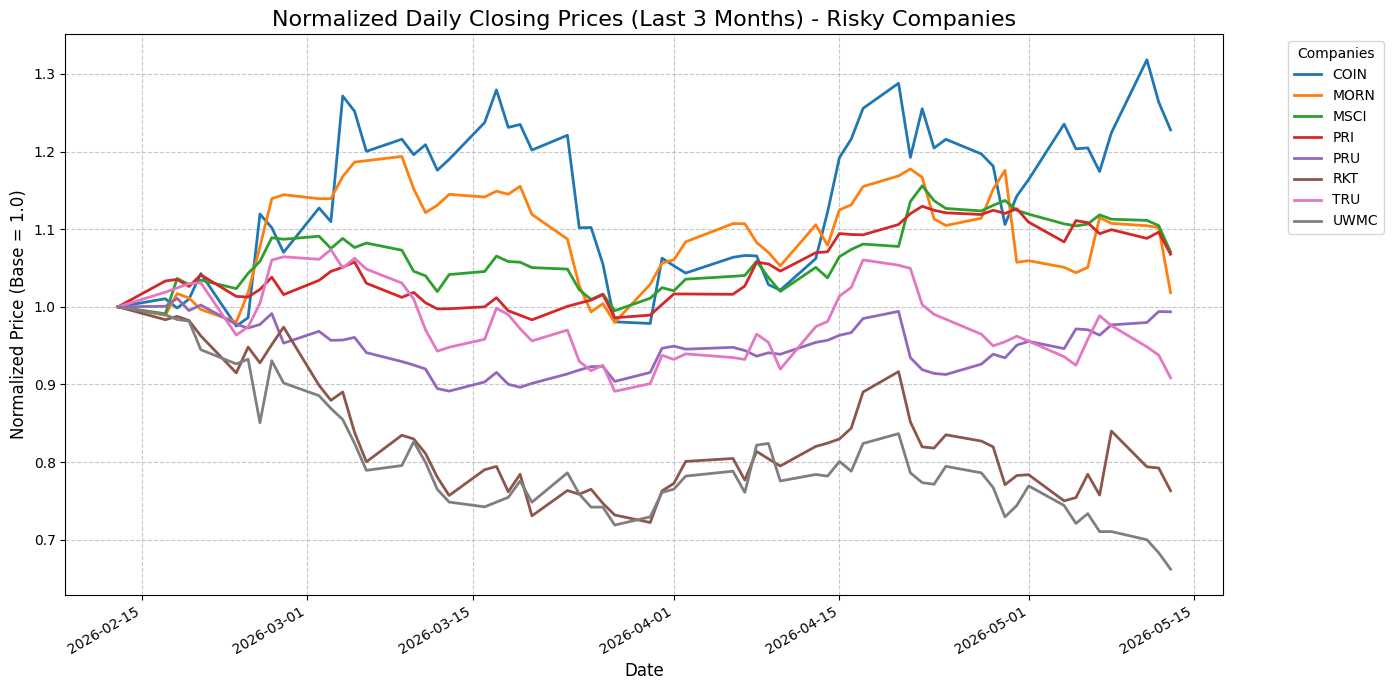

In [311]:
# Normalizing the data: dividing all rows by the first row (index 0)
# This forces all stock prices to start exactly at 1.0 on the first day
df_normalized_2 = df_close_2 / df_close_2.iloc[0]

# Creating the plot
# Pandas has a built-in plot function that automatically handles dates on the x-axis
plt.figure(figsize=(14, 7))
df_normalized_2.plot(ax=plt.gca(), linewidth=2)

# Adding titles and labels for clarity
plt.title('Normalized Daily Closing Prices (Last 3 Months) - Risky Companies', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price (Base = 1.0)', fontsize=12)

# Adding a grid to make it easier to read percentage changes
plt.grid(True, linestyle='--', alpha=0.7)

# Placing the legend outside the plot so it doesn't cover the lines
plt.legend(title='Companies', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjusting layout and displaying the chart
plt.tight_layout()
plt.show()

Observation on the Geopolitical Impact (Strait of Hormuz):
Looking at the normalized price chart for our "Risky Companies" (Low Cap / High Beta), the impact of the geopolitical tensions is visible but varies significantly among the companies.

1. Visibly Affected: 
Companies like UWMC (grey), RKT (brown): show a significant drop in their value, in particular UWMC recorded a significant drop corresponding to the closure of the Strait of Hormuz (2026-03-01). Currently, the value of UWMC stands between 70 and 80% of what it was three months ago, while the value of RKT is even below 70% of its starting value.

2. Balancing highs and lows: 
TRU's (pink) performance has been quite unusual, with many ups and downs, which somewhat balance each other out given that its current value is 90% of its starting value.
A similar pattern can be seen in PRU (purple), which, although it has traded at lower levels than TRU over the long term and lost more value, is currently trading at a level very close to 100% of where it was three months ago.

3. Up-and-down trend: 
COIN (blue) shows a very distinctive trend, with much more pronounced peaks and troughs compared to all other companies. One notable feature to bear in mind is that, shortly after the closure of the Strait of Hormuz, its value rose by around 10%. There was a significant drop in early April, followed by further fluctuations, until a sharp rise around mid-April. Further fluctuations have been recorded, up to the present day, where the value stands at just over 120% of its starting point.
MORN (orange) shows a similar trend, albeit with lower peaks; it was only during the first half of April that it recorded higher growth than COIN. As of today, its value is only slightly higher than it was three months ago (less than 10%).

4. Stable trends and a final increase in value:
The MSCI (green) and PRI (red) indices show relatively modest fluctuations, which remained within 10% until mid-April, when they rose slightly above this level. To date, they have recorded growth of just under 10% compared with their initial value.

Conclusion: 
‘Risky Companies’ exhibit more unpredictable behaviour than the ‘Safe Giants’ analysed earlier. These companies experience more pronounced ups and downs. Interestingly, some of them show very high growth rates, sometimes even higher than those of the stable companies mentioned earlier!